# Time-Series Forecasting With a Custom GRU

This notebook builds a full forecasting pipeline from scratch.

We use the same forecasting setup on two real-world datasets:

1. Daily minimum temperatures in Melbourne.
2. Electricity consumption with weather context.

The assignment asks for three ideas to stay front-and-center:

- how raw time series values are converted into supervised learning windows.
- how sequence models use past information.
- where models fail and why.

Models covered in this notebook:

- MLPBaseline: a lag-feature baseline with no recurrent memory
- CustomGRU: implemented manually from gate equations
- LSTMRegressor: prebuilt comparison model
- TransformerRegressor: prebuilt comparison model

We also run an ablation study for the custom GRU with:

- half the original window size
- the original window size
- double the original window size

In [104]:
import copy
import math
import random
import shutil
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import kagglehub
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# Required assignment parameters (R.No. 102317125)
window_size = 10
prediction_horizon = 2
hidden_size = 14

batch_size = 64
learning_rate = 1e-3
max_epochs = 30
patience = 5
train_ratio = 0.70
val_ratio = 0.15
seed = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu



The required electricity dataset here is Kaggle: sudhirsingh27/electricity-consumption-based-on-weather-data, which is already a daily dataset and includes both electricity usage and weather context.

That design choice matters:

- the temperature dataset stays a clean univariate forecasting problem,
- the electricity dataset becomes a multivariate forecasting problem because we feed past weather together with past consumption,
- the target remains future electricity consumption, so we can compare models on the same forecasting objective.

A useful limitation is still present: the models only receive historical weather values inside the input window. They do not get the future weather for the next two days, so sudden weather-driven changes can still cause forecasting errors.

The notebook will automatically download the files into a local data/ folder if they are missing.

In [105]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

DATA_SOURCES = {
    "temperature": {
        "path": DATA_DIR / "daily_min_temperatures.csv",
        "url": "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv",
    },
    "electricity": {
        "path": DATA_DIR / "electricity_consumption_based_weather_dataset.csv",
        "handle": "sudhirsingh27/electricity-consumption-based-on-weather-data",
        "filename": "electricity_consumption_based_weather_dataset.csv",
    },
}


def set_seed(value: int = seed) -> None:
    random.seed(value)
    np.random.seed(value)
    torch.manual_seed(value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(value)


def ensure_data_files() -> None:
    temperature_item = DATA_SOURCES["temperature"]
    if not temperature_item["path"].exists():
        print(f"Downloading {temperature_item['path'].name} ...")
        urlretrieve(temperature_item["url"], temperature_item["path"])

    electricity_item = DATA_SOURCES["electricity"]
    if not electricity_item["path"].exists():
        print(f"Downloading {electricity_item['path'].name} via kagglehub ...")
        cache_dir = Path(kagglehub.dataset_download(electricity_item["handle"]))
        shutil.copy2(cache_dir / electricity_item["filename"], electricity_item["path"])


class StandardScaler1D:
    """Simple scaler so the transformation logic stays visible."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, values):
        values = np.asarray(values, dtype=np.float32)
        self.mean_ = float(values.mean())
        self.std_ = float(values.std())
        if self.std_ == 0.0:
            self.std_ = 1.0
        return self

    def transform(self, values):
        values = np.asarray(values, dtype=np.float32)
        return (values - self.mean_) / self.std_

    def inverse_transform(self, values):
        values = np.asarray(values, dtype=np.float32)
        return values * self.std_ + self.mean_


class StandardScalerND:
    """Column-wise scaler for multivariate time-series features."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, values):
        values = np.asarray(values, dtype=np.float32)
        self.mean_ = values.mean(axis=0, keepdims=True)
        self.std_ = values.std(axis=0, keepdims=True)
        self.std_[self.std_ == 0.0] = 1.0
        return self

    def transform(self, values):
        values = np.asarray(values, dtype=np.float32)
        return (values - self.mean_) / self.std_


def load_temperature_dataset(csv_path: Path) -> dict:
    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"])
    frame = df.rename(columns={"Date": "timestamp", "Temp": "temperature"}).copy()
    frame["dataset"] = "Daily Minimum Temperatures"
    return {
        "name": "Daily Minimum Temperatures",
        "frame": frame[["timestamp", "temperature", "dataset"]],
        "feature_columns": ["temperature"],
        "target_column": "temperature",
    }


def load_electricity_dataset(csv_path: Path) -> dict:
    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(df["date"])

    numeric_columns = ["AWND", "PRCP", "TMAX", "TMIN", "daily_consumption"]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    frame = (
        df.rename(columns={"date": "timestamp"})
        .sort_values("timestamp")
        .reset_index(drop=True)
        .copy()
    )
    frame[numeric_columns] = frame[numeric_columns].interpolate().bfill().ffill()
    frame["dataset"] = "Daily Consumption With Weather Context"

    return {
        "name": "Daily Consumption With Weather Context",
        "frame": frame[["timestamp", "AWND", "PRCP", "TMAX", "TMIN", "daily_consumption", "dataset"]],
        "feature_columns": ["daily_consumption", "AWND", "PRCP", "TMAX", "TMIN"],
        "target_column": "daily_consumption",
    }


ensure_data_files()

raw_series_catalog = {
    "Daily Minimum Temperatures": load_temperature_dataset(DATA_SOURCES["temperature"]["path"]),
    "Daily Consumption With Weather Context": load_electricity_dataset(DATA_SOURCES["electricity"]["path"]),
}

for name, dataset_info in raw_series_catalog.items():
    frame = dataset_info["frame"]
    print(
        f"{name}: {len(frame)} rows, range = {frame['timestamp'].min().date()} to {frame['timestamp'].max().date()}, "
        f"features = {dataset_info['feature_columns']}"
    )

Daily Minimum Temperatures: 3650 rows, range = 1981-01-01 to 1990-12-31, features = ['temperature']
Daily Consumption With Weather Context: 1433 rows, range = 2006-12-16 to 2010-11-26, features = ['daily_consumption', 'AWND', 'PRCP', 'TMAX', 'TMIN']


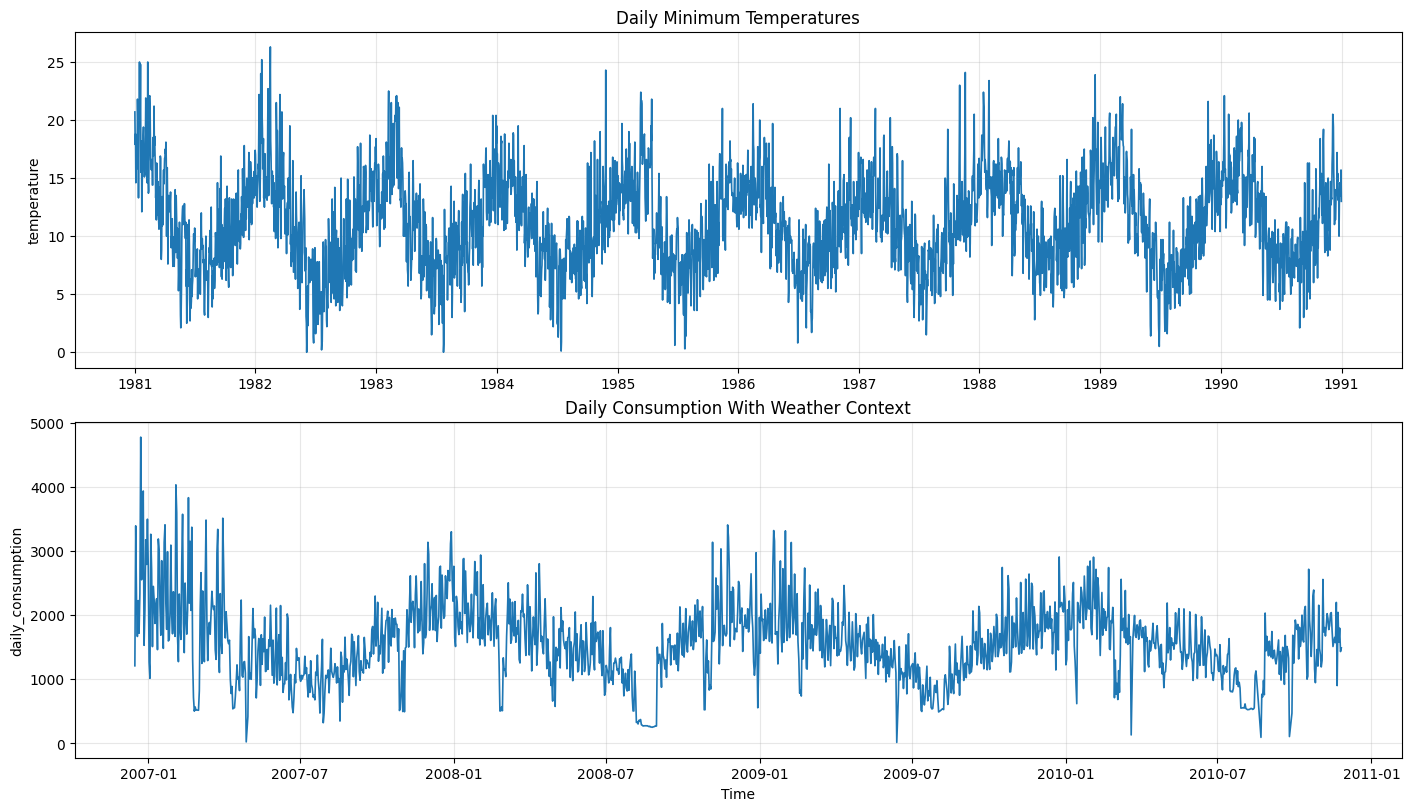

In [106]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

for ax, (name, dataset_info) in zip(axes, raw_series_catalog.items()):
    frame = dataset_info["frame"]
    target_column = dataset_info["target_column"]
    ax.plot(frame["timestamp"], frame[target_column], linewidth=1.2)
    ax.set_title(name)
    ax.set_ylabel(target_column)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.show()


A forecasting model does not see the future. We preserve that rule in two ways:

1. Chronological split only: the earliest chunk is training data, the middle chunk is validation data, and the latest chunk is test data.
2. Windowed supervision: each input window contains only past values, and each target contains the next prediction_horizon values.

For the electricity dataset, the input window contains past consumption plus past weather and the target still contains only the future daily_consumption values.

An important detail is that validation and test windows are allowed to *look back* into earlier periods. That is realistic. When forecasting on day t, we are allowed to use observed history from days <t; we are simply not allowed to train on the future targets.

In [107]:
def build_windowed_problem(dataset_info: dict, current_window_size: int, horizon: int):
    frame = dataset_info["frame"].sort_values("timestamp").reset_index(drop=True).copy()
    feature_columns = dataset_info["feature_columns"]
    target_column = dataset_info["target_column"]

    feature_values = frame[feature_columns].to_numpy(dtype=np.float32)
    target_values = frame[target_column].to_numpy(dtype=np.float32)
    timestamps = frame["timestamp"].to_numpy()

    train_end = int(len(target_values) * train_ratio)
    val_end = int(len(target_values) * (train_ratio + val_ratio))

    feature_scaler = StandardScalerND().fit(feature_values[:train_end])
    target_scaler = StandardScaler1D().fit(target_values[:train_end])

    scaled_features = feature_scaler.transform(feature_values)
    scaled_target = target_scaler.transform(target_values)

    x_scaled, y_scaled = [], []
    x_target_raw, y_target_raw = [], []
    x_feature_raw = []
    x_times, y_times = [], []
    splits = []

    # Each sample is a direct multi-step forecasting pair:
    # input  = historical features over [t : t + window_size]
    # target = future target values over [t + window_size : t + window_size + horizon]
    for start in range(len(target_values) - current_window_size - horizon + 1):
        input_end = start + current_window_size
        target_end = input_end + horizon

        target_start_idx = input_end
        target_end_idx = target_end

        if target_end_idx <= train_end:
            split_name = "train"
        elif target_start_idx >= train_end and target_end_idx <= val_end:
            split_name = "val"
        elif target_start_idx >= val_end:
            split_name = "test"
        else:
            # Skip boundary cases where the target straddles two splits.
            continue

        x_scaled.append(scaled_features[start:input_end])
        y_scaled.append(scaled_target[input_end:target_end])
        x_target_raw.append(target_values[start:input_end])
        y_target_raw.append(target_values[input_end:target_end])
        x_feature_raw.append(feature_values[start:input_end])
        x_times.append(timestamps[start:input_end])
        y_times.append(timestamps[input_end:target_end])
        splits.append(split_name)

    split_array = np.asarray(splits)
    x_scaled = np.asarray(x_scaled, dtype=np.float32).reshape(-1, current_window_size, len(feature_columns))
    y_scaled = np.asarray(y_scaled, dtype=np.float32).reshape(-1, horizon)
    x_target_raw = np.asarray(x_target_raw, dtype=np.float32).reshape(-1, current_window_size)
    y_target_raw = np.asarray(y_target_raw, dtype=np.float32).reshape(-1, horizon)
    x_feature_raw = np.asarray(x_feature_raw, dtype=np.float32).reshape(-1, current_window_size, len(feature_columns))
    x_times = np.asarray(x_times, dtype="datetime64[ns]").reshape(-1, current_window_size)
    y_times = np.asarray(y_times, dtype="datetime64[ns]").reshape(-1, horizon)

    sample_table = {
        split_name: {
            "x_scaled": x_scaled[split_array == split_name],
            "y_scaled": y_scaled[split_array == split_name],
            "x_target_raw": x_target_raw[split_array == split_name],
            "y_target_raw": y_target_raw[split_array == split_name],
            "x_feature_raw": x_feature_raw[split_array == split_name],
            "x_times": x_times[split_array == split_name],
            "y_times": y_times[split_array == split_name],
        }
        for split_name in ["train", "val", "test"]
    }

    loaders = {}
    for split_name, split_data in sample_table.items():
        x_tensor = torch.as_tensor(split_data["x_scaled"], dtype=torch.float32)
        y_tensor = torch.as_tensor(split_data["y_scaled"], dtype=torch.float32)
        dataset = TensorDataset(x_tensor, y_tensor)
        loaders[split_name] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split_name == "train"),
        )

    return {
        "name": frame["dataset"].iloc[0],
        "frame": frame,
        "feature_values": feature_values,
        "target_values": target_values,
        "timestamps": timestamps,
        "train_end": train_end,
        "val_end": val_end,
        "window_size": current_window_size,
        "horizon": horizon,
        "feature_columns": feature_columns,
        "target_column": target_column,
        "num_features": len(feature_columns),
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "samples": sample_table,
        "loaders": loaders,
    }


problems = {
    name: build_windowed_problem(dataset_info, window_size, prediction_horizon)
    for name, dataset_info in raw_series_catalog.items()
}

for name, problem in problems.items():
    print(
        f"{name}: train={len(problem['samples']['train']['x_scaled'])}, "
        f"val={len(problem['samples']['val']['x_scaled'])}, "
        f"test={len(problem['samples']['test']['x_scaled'])}"
    )

Daily Minimum Temperatures: train=2544, val=546, test=547
Daily Consumption With Weather Context: train=992, val=214, test=214


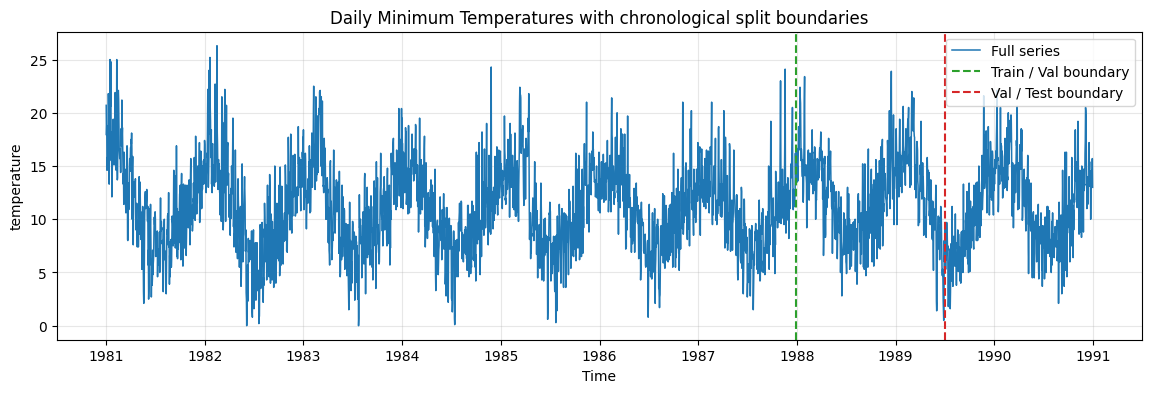

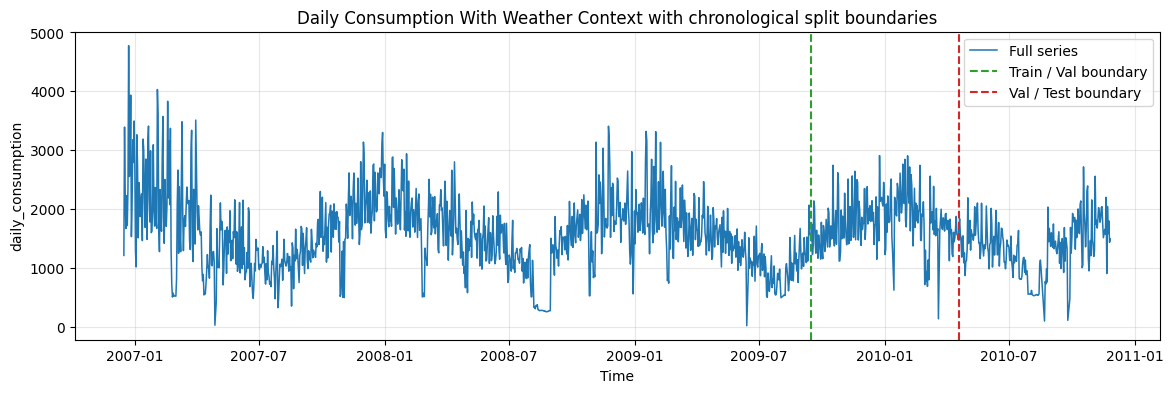

In [108]:
def plot_split_boundaries(problem):
    frame = problem["frame"]
    train_cut = frame.loc[problem["train_end"] - 1, "timestamp"]
    val_cut = frame.loc[problem["val_end"] - 1, "timestamp"]

    plt.figure(figsize=(14, 4))
    plt.plot(frame["timestamp"], frame[problem["target_column"]], label="Full series", linewidth=1.1)
    plt.axvline(train_cut, color="tab:green", linestyle="--", label="Train / Val boundary")
    plt.axvline(val_cut, color="tab:red", linestyle="--", label="Val / Test boundary")
    plt.title(f"{problem['name']} with chronological split boundaries")
    plt.xlabel("Time")
    plt.ylabel(problem["target_column"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


for problem in problems.values():
    plot_split_boundaries(problem)

In [109]:
# Inspecting one raw window makes the supervised learning conversion explicit.
example_problem = problems["Daily Consumption With Weather Context"]
example_idx = 0

example_input_table = pd.DataFrame(
    example_problem["samples"]["train"]["x_feature_raw"][example_idx],
    columns=example_problem["feature_columns"],
)
example_input_table.insert(0, "timestamp", example_problem["samples"]["train"]["x_times"][example_idx])
example_input_table["role"] = "input"

example_target_table = pd.DataFrame(
    {
        "timestamp": example_problem["samples"]["train"]["y_times"][example_idx],
        example_problem["target_column"]: example_problem["samples"]["train"]["y_target_raw"][example_idx],
        "role": "target",
    }
)

print("Input window given to the model for the electricity dataset:")
display(example_input_table)
print("Future values the model must predict:")
display(example_target_table)

Input window given to the model for the electricity dataset:


,timestamp,daily_consumption,AWND,PRCP,TMAX,TMIN,role
0,2006-12-16,1209.176025,2.5,0.000000,10.6,5.0,input
1,2006-12-17,3390.459961,2.6,0.000000,13.3,5.6,input
2,2006-12-18,2203.825928,2.4,0.000000,15.0,6.7,input
3,2006-12-19,1666.193970,2.4,0.000000,7.2,2.2,input
4,2006-12-20,2225.748047,2.4,0.000000,7.2,1.1,input
5,2006-12-21,1716.624023,2.3,0.000000,12.2,3.3,input
6,2006-12-22,2341.337891,2.3,11.900000,9.4,3.9,input
7,2006-12-23,4773.386230,3.0,19.799999,15.0,8.9,input
8,2006-12-24,2550.011963,3.4,0.000000,11.1,6.1,input
9,2006-12-25,2743.120117,2.2,9.400000,7.2,3.9,input


Future values the model must predict:


,timestamp,daily_consumption,role
0,2006-12-26,3934.110107,target
1,2006-12-27,1528.760010,target


In [110]:
first_train_batch = next(iter(example_problem["loaders"]["train"]))
x_batch, y_batch = first_train_batch

print("Model input shape:", tuple(x_batch.shape))
print("Model target shape:", tuple(y_batch.shape))
print()
print("The recurrent models see tensors shaped as:")
print("  [batch, window_size, features] =", tuple(x_batch.shape))
print()
print("Feature order:", example_problem["feature_columns"])
print()
print("The first scaled training window is:")
display(pd.DataFrame(x_batch[0].tolist(), columns=example_problem["feature_columns"]))
print()
print("The 2-step target the model must predict is:")
print(y_batch[0].tolist())

Model input shape: (64, 10, 5)
Model target shape: (64, 2)

The recurrent models see tensors shaped as:
  [batch, window_size, features] = (64, 10, 5)

Feature order: ['daily_consumption', 'AWND', 'PRCP', 'TMAX', 'TMIN']

The first scaled training window is:


,daily_consumption,AWND,PRCP,TMAX,TMIN
0,0.170392,-0.493184,0.439665,-0.304354,0.190180
1,0.268478,1.411986,0.351370,-0.471645,0.190180
2,-0.320066,-0.311739,2.232070,0.128635,0.059618
3,-0.840252,-0.946796,2.028990,0.404173,0.190180
4,0.462332,-1.128241,-0.346167,0.620668,0.483944
5,-0.456647,-0.402462,1.040077,0.728915,0.603625
6,0.631066,1.774875,-0.346167,0.404173,0.364262
7,-0.062059,-0.402462,-0.346167,0.187679,0.124899
8,0.105725,-0.946796,-0.346167,0.354970,0.124899
9,-0.479712,-0.130295,-0.346167,0.236882,0.059618



The 2-step target the model must predict is:
[0.0764622762799263, -0.2085118442773819]



The baseline MLP receives the same lag window, but it treats that window as a fixed feature vector. It has no recurrent hidden state.

The custom GRU below is implemented manually from the gate equations:

- update gate z_t decides how much past state to keep,
- reset gate r_t decides how strongly to reuse past state when creating the candidate,
- candidate state n_t mixes the new input with the gated history,
- final hidden state h_t blends the old and new information.

In other words, the GRU is sequence-aware because it updates a hidden summary one time step at a time.

In [111]:
class MLPBaseline(nn.Module):
    def __init__(self, current_window_size: int, input_size: int, forecast_horizon: int, hidden_units: int):
        super().__init__()
        flattened_size = current_window_size * input_size
        self.network = nn.Sequential(
            nn.Linear(flattened_size, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, forecast_horizon),
        )

    def forward(self, x):
        # The MLP loses explicit temporal recurrence because we flatten the full window.
        x = x.reshape(x.size(0), -1)
        return self.network(x)


class CustomGRU(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, forecast_horizon: int):
        super().__init__()
        self.hidden_units = hidden_units

        self.W_xz = nn.Parameter(torch.randn(input_size, hidden_units) * 0.1)
        self.W_hz = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.b_z = nn.Parameter(torch.zeros(hidden_units))

        self.W_xr = nn.Parameter(torch.randn(input_size, hidden_units) * 0.1)
        self.W_hr = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.b_r = nn.Parameter(torch.zeros(hidden_units))

        self.W_xn = nn.Parameter(torch.randn(input_size, hidden_units) * 0.1)
        self.W_hn = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.b_n = nn.Parameter(torch.zeros(hidden_units))

        self.output = nn.Linear(hidden_units, forecast_horizon)

    def forward(self, x):
        batch_size_local = x.size(0)
        hidden = torch.zeros(batch_size_local, self.hidden_units, device=x.device)

        for step in range(x.size(1)):
            x_t = x[:, step, :]

            # Update gate: keep old memory when z is high.
            z_t = torch.sigmoid(x_t @ self.W_xz + hidden @ self.W_hz + self.b_z)

            # Reset gate: reduce the influence of old memory when building the candidate.
            r_t = torch.sigmoid(x_t @ self.W_xr + hidden @ self.W_hr + self.b_r)

            candidate = torch.tanh(x_t @ self.W_xn + (r_t * hidden) @ self.W_hn + self.b_n)

            # Blend previous state and candidate state.
            hidden = (1.0 - z_t) * candidate + z_t * hidden

        return self.output(hidden)


class LSTMRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, forecast_horizon: int):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_units, batch_first=True)
        self.output = nn.Linear(hidden_units, forecast_horizon)

    def forward(self, x):
        _, (hidden_state, _) = self.lstm(x)
        return self.output(hidden_state[-1])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        positions = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class TransformerRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, forecast_horizon: int):
        super().__init__()
        self.input_projection = nn.Linear(input_size, hidden_units)
        self.position = PositionalEncoding(hidden_units)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_units,
            nhead=2,
            dim_feedforward=hidden_units * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.output = nn.Linear(hidden_units, forecast_horizon)

    def forward(self, x):
        encoded = self.input_projection(x)
        encoded = self.position(encoded)
        encoded = self.encoder(encoded)
        # We read the final token representation because it summarizes the full input window.
        return self.output(encoded[:, -1, :])


model_factories = {
    "MLP baseline": lambda problem: MLPBaseline(problem["window_size"], problem["num_features"], prediction_horizon, hidden_size),
    "Custom GRU": lambda problem: CustomGRU(problem["num_features"], hidden_size, prediction_horizon),
    "LSTM": lambda problem: LSTMRegressor(problem["num_features"], hidden_size, prediction_horizon),
    "Transformer": lambda problem: TransformerRegressor(problem["num_features"], hidden_size, prediction_horizon),
}

Training Utilities:

We optimize MSE because it strongly penalizes large misses. That is helpful in forecasting because large misses are exactly the failures we care about inspecting.

Early stopping uses validation loss only. This keeps the test set untouched until the very end.

In [112]:
def evaluate_loss(model, data_loader, criterion):
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            losses.append(float(criterion(preds, yb).item()))
    return float(np.mean(losses))


def train_model(model, problem):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_state = None
    best_val = float("inf")
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []

        for xb, yb in problem["loaders"]["train"]:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(float(loss.item()))

        train_loss = float(np.mean(batch_losses))
        val_loss = evaluate_loss(model, problem["loaders"]["val"], criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def predict_scaled(model, data_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            preds.append(np.asarray(model(xb).cpu().tolist(), dtype=np.float32))
            trues.append(np.asarray(yb.tolist(), dtype=np.float32))
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)


def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = math.sqrt(mse)
    return {"MSE": mse, "MAE": mae, "RMSE": rmse}


def build_prediction_frame(target_times, y_true, y_pred):
    rows = []
    for sample_idx in range(len(y_true)):
        for step_idx in range(y_true.shape[1]):
            rows.append(
                {
                    "sample_idx": sample_idx,
                    "step_ahead": step_idx + 1,
                    "timestamp": pd.Timestamp(target_times[sample_idx, step_idx]),
                    "actual": float(y_true[sample_idx, step_idx]),
                    "predicted": float(y_pred[sample_idx, step_idx]),
                    "abs_error": float(abs(y_true[sample_idx, step_idx] - y_pred[sample_idx, step_idx])),
                }
            )
    return pd.DataFrame(rows)


def run_single_experiment(problem, model_name, model_builder):
    set_seed(seed)
    model = model_builder(problem).to(device)
    history = train_model(model, problem)

    pred_scaled, true_scaled = predict_scaled(model, problem["loaders"]["test"])
    target_scaler = problem["target_scaler"]
    pred_raw = target_scaler.inverse_transform(pred_scaled)
    true_raw = target_scaler.inverse_transform(true_scaled)

    metrics = compute_metrics(true_raw, pred_raw)
    prediction_frame = build_prediction_frame(problem["samples"]["test"]["y_times"], true_raw, pred_raw)

    sample_errors = np.abs(true_raw - pred_raw).max(axis=1)
    worst_sample_idx = int(np.argmax(sample_errors))

    return {
        "model_name": model_name,
        "history": history,
        "metrics": metrics,
        "pred_scaled": pred_scaled,
        "true_scaled": true_scaled,
        "pred_raw": pred_raw,
        "true_raw": true_raw,
        "prediction_frame": prediction_frame,
        "worst_sample_idx": worst_sample_idx,
    }

Run All Default Models:

All four models below use the same main assignment settings:

- window_size = 10
- prediction_horizon = 2
- hidden_size = 14

In [113]:
default_runs = {}
metrics_rows = []

for dataset_name, problem in problems.items():
    default_runs[dataset_name] = {}
    print(f"Running default models on: {dataset_name}")
    for model_name, model_builder in model_factories.items():
        run = run_single_experiment(problem, model_name, model_builder)
        default_runs[dataset_name][model_name] = run
        metrics_rows.append(
            {
                "dataset": dataset_name,
                "model": model_name,
                **run["metrics"],
                "epochs_trained": len(run["history"]["train_loss"]),
            }
        )
        print(
            f"  {model_name:<12} | "
            f"MSE={run['metrics']['MSE']:.4f} | "
            f"MAE={run['metrics']['MAE']:.4f} | "
            f"RMSE={run['metrics']['RMSE']:.4f}"
        )
    print()

metrics_df = pd.DataFrame(metrics_rows).sort_values(["dataset", "RMSE", "MAE"]).reset_index(drop=True)
metrics_df.round(4)

Running default models on: Daily Minimum Temperatures


  MLP baseline | MSE=5.7539 | MAE=1.8605 | RMSE=2.3987
  Custom GRU   | MSE=5.7237 | MAE=1.8574 | RMSE=2.3924
  LSTM         | MSE=5.7939 | MAE=1.8634 | RMSE=2.4071
  Transformer  | MSE=5.6609 | MAE=1.8450 | RMSE=2.3793

Running default models on: Daily Consumption With Weather Context
  MLP baseline | MSE=125572.3828 | MAE=272.5474 | RMSE=354.3619
  Custom GRU   | MSE=128007.3828 | MAE=275.2765 | RMSE=357.7812
  LSTM         | MSE=131583.3906 | MAE=284.4258 | RMSE=362.7442
  Transformer  | MSE=131511.8281 | MAE=283.5300 | RMSE=362.6456



,dataset,model,MSE,MAE,RMSE,epochs_trained
0,Daily Consumption With Weather Context,MLP baseline,125572.3828,272.5474,354.3619,13
1,Daily Consumption With Weather Context,Custom GRU,128007.3828,275.2765,357.7812,16
2,Daily Consumption With Weather Context,Transformer,131511.8281,283.5300,362.6456,8
3,Daily Consumption With Weather Context,LSTM,131583.3906,284.4258,362.7442,13
4,Daily Minimum Temperatures,Transformer,5.6609,1.8450,2.3793,30
5,Daily Minimum Temperatures,Custom GRU,5.7237,1.8574,2.3924,30
6,Daily Minimum Temperatures,MLP baseline,5.7539,1.8605,2.3987,27
7,Daily Minimum Temperatures,LSTM,5.7939,1.8634,2.4071,30


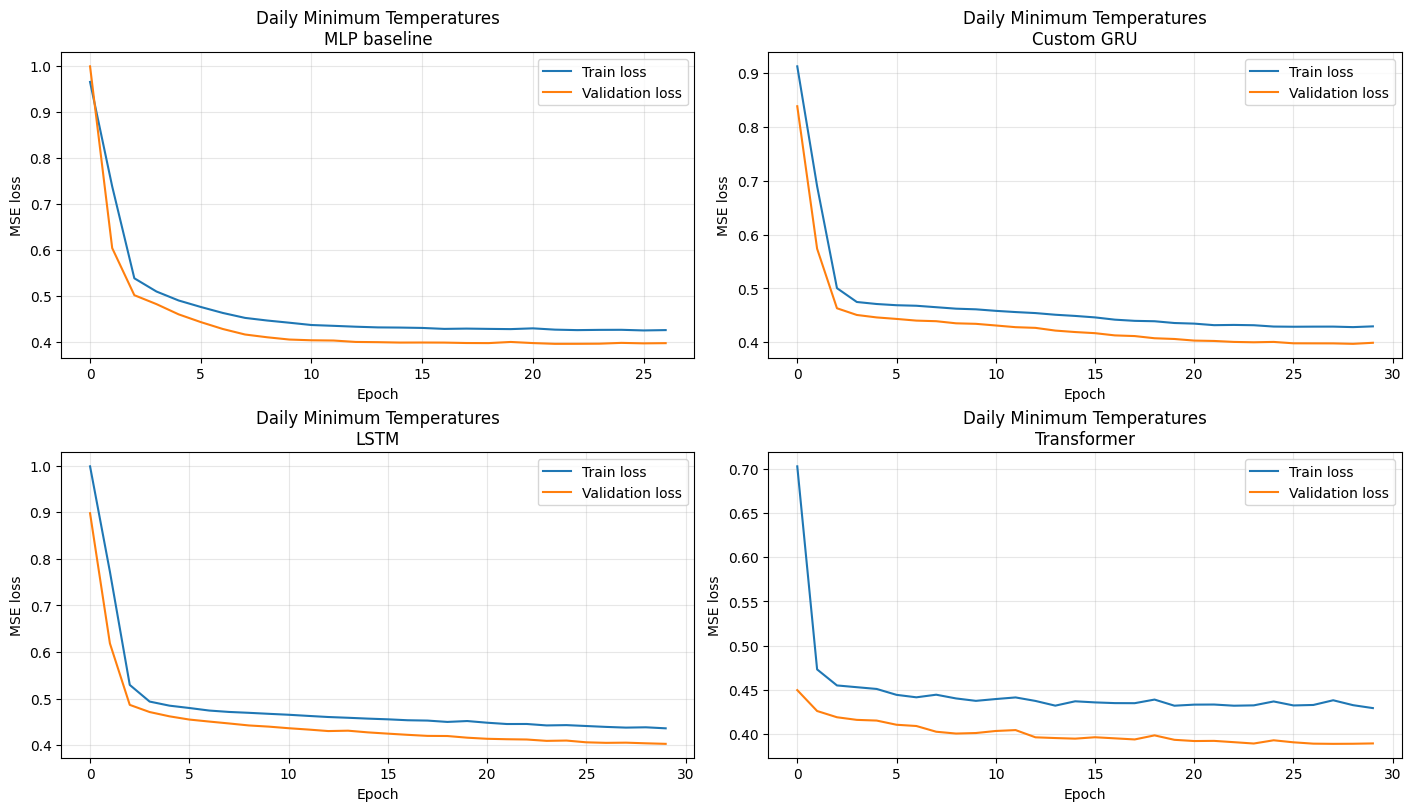

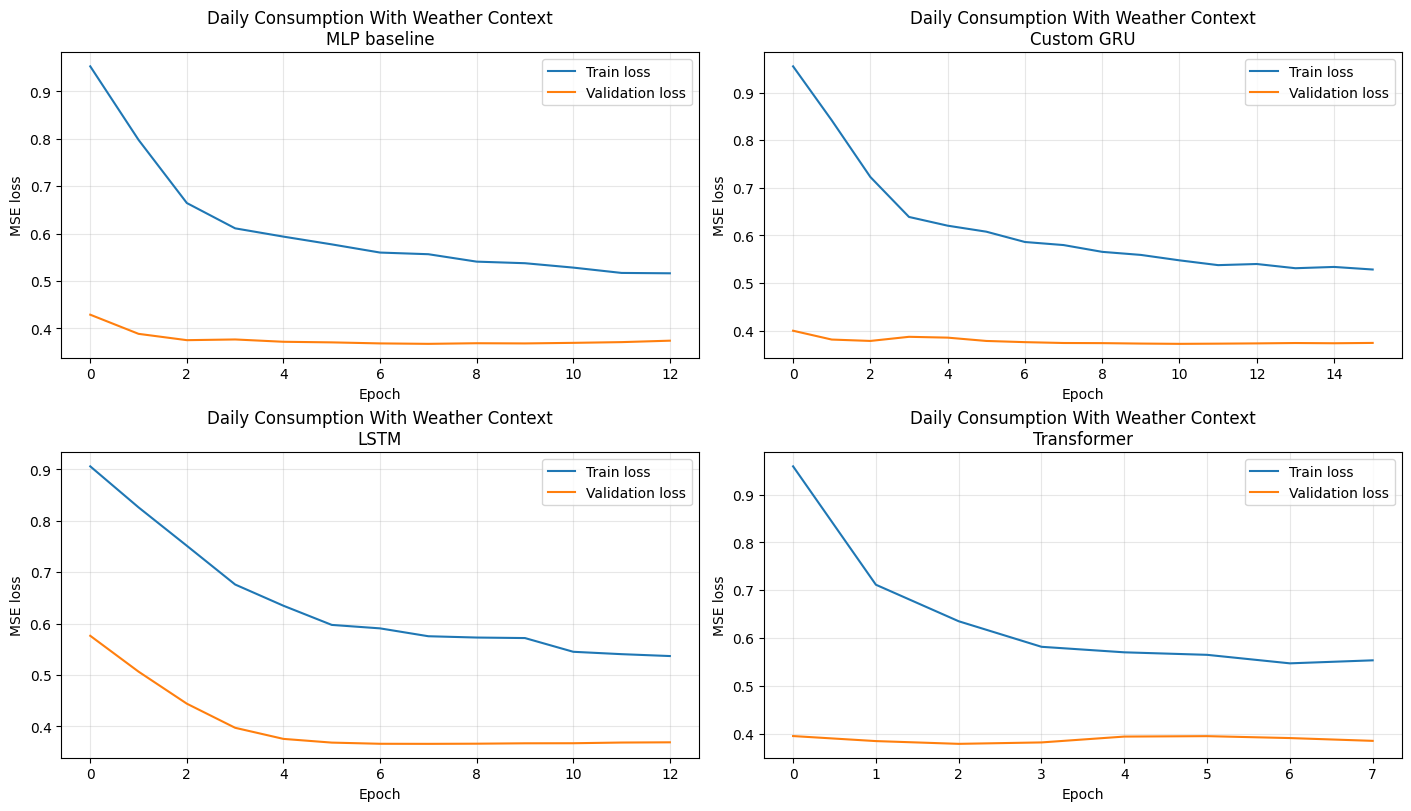

In [114]:
def plot_loss_curves(dataset_name, dataset_runs):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    axes = axes.ravel()
    for ax, (model_name, run) in zip(axes, dataset_runs.items()):
        ax.plot(run["history"]["train_loss"], label="Train loss")
        ax.plot(run["history"]["val_loss"], label="Validation loss")
        ax.set_title(f"{dataset_name}\n{model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE loss")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.show()


for dataset_name, dataset_runs in default_runs.items():
    plot_loss_curves(dataset_name, dataset_runs)

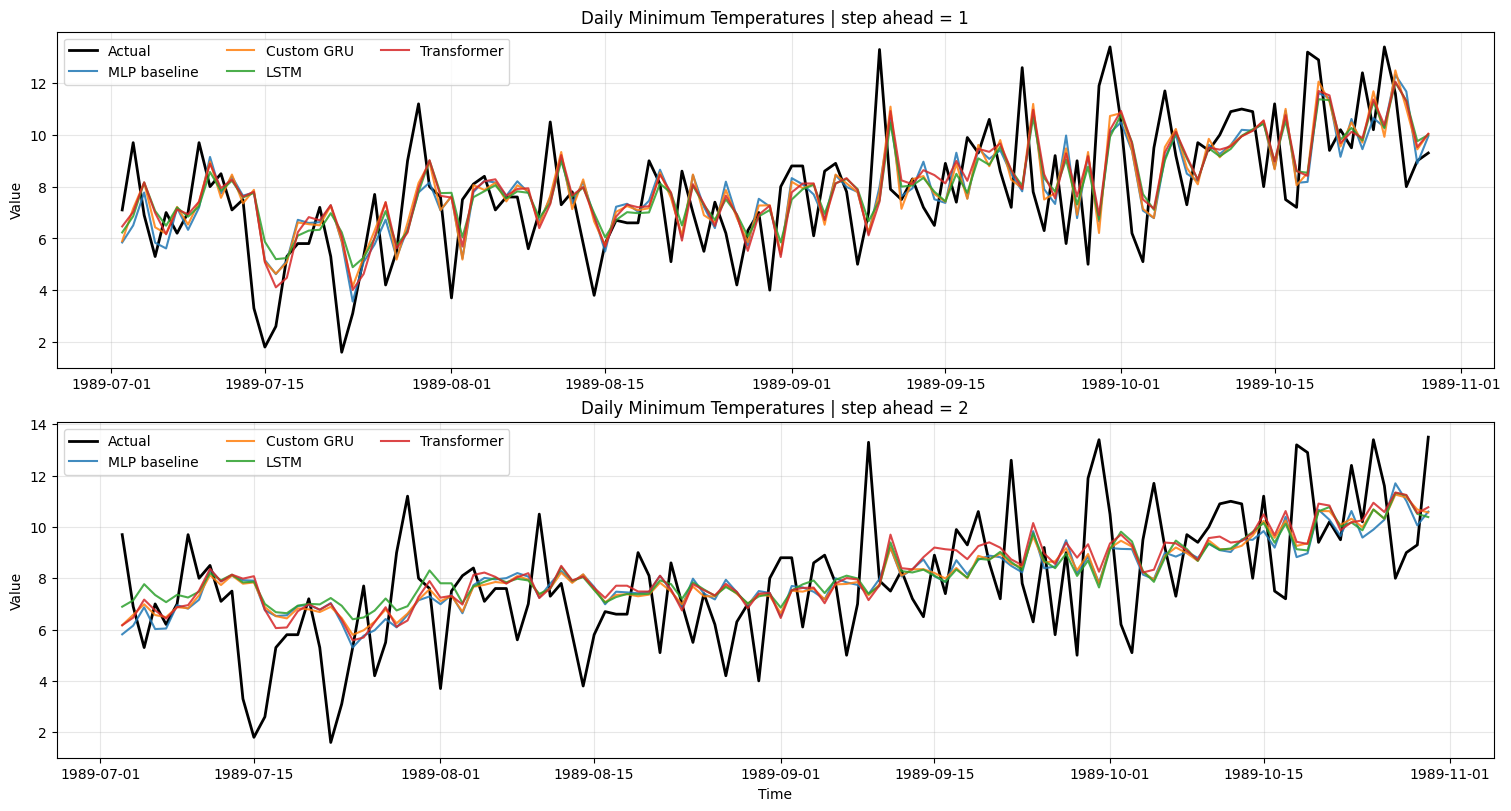

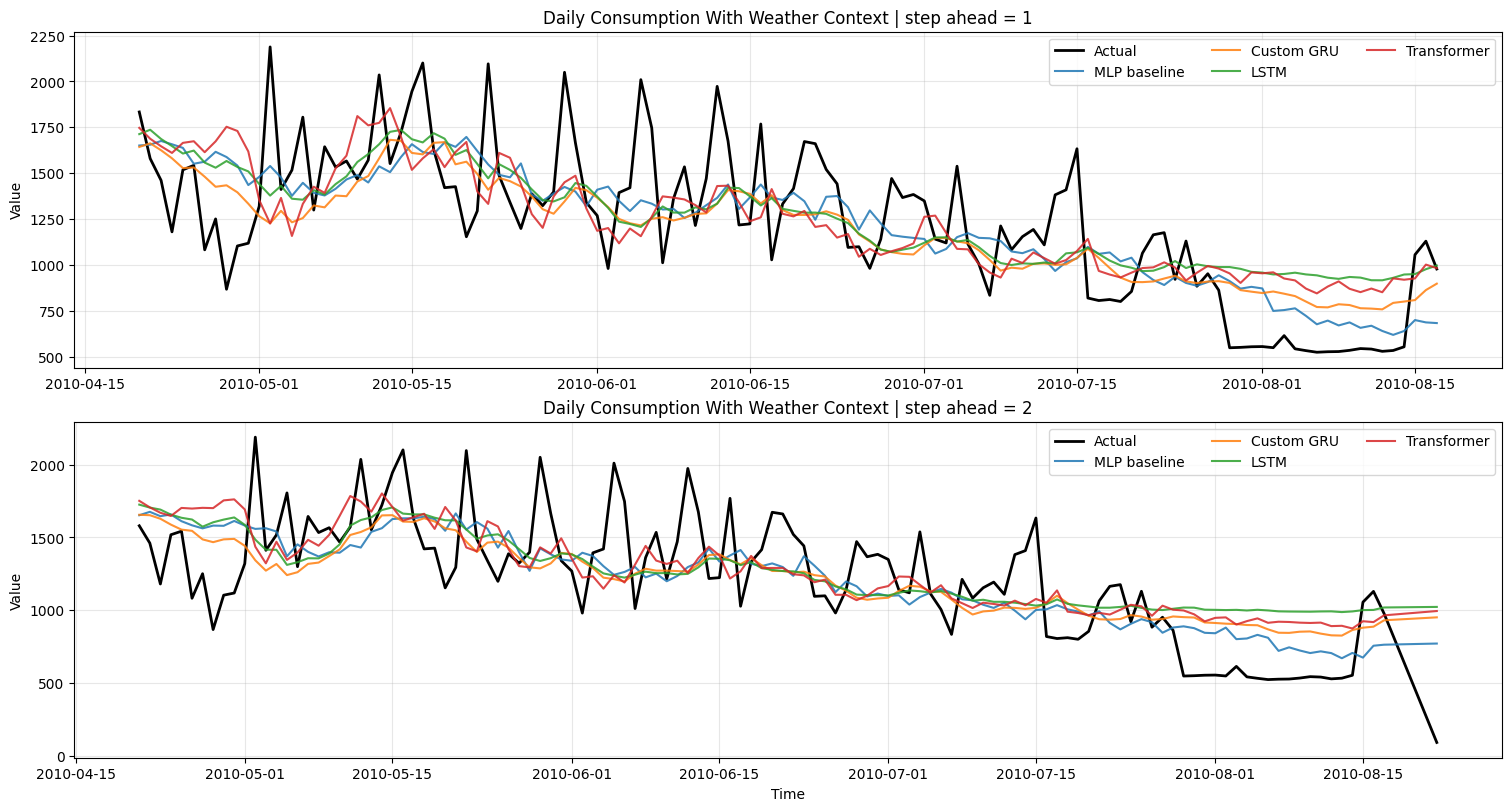

In [115]:
def plot_prediction_vs_actual(dataset_name, dataset_runs, max_points: int = 120):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)

    for step_idx, ax in enumerate(axes, start=1):
        reference_run = next(iter(dataset_runs.values()))
        step_mask = reference_run["prediction_frame"]["step_ahead"] == step_idx
        reference_frame = reference_run["prediction_frame"].loc[step_mask].head(max_points)

        ax.plot(
            reference_frame["timestamp"],
            reference_frame["actual"],
            label="Actual",
            color="black",
            linewidth=2.0,
        )

        for model_name, run in dataset_runs.items():
            step_frame = run["prediction_frame"].loc[run["prediction_frame"]["step_ahead"] == step_idx].head(max_points)
            ax.plot(step_frame["timestamp"], step_frame["predicted"], label=model_name, alpha=0.85)

        ax.set_title(f"{dataset_name} | step ahead = {step_idx}")
        ax.set_ylabel("Value")
        ax.grid(alpha=0.3)
        ax.legend(ncol=3)

    axes[-1].set_xlabel("Time")
    plt.show()


for dataset_name, dataset_runs in default_runs.items():
    plot_prediction_vs_actual(dataset_name, dataset_runs)

Where the Custom GRU Fails

Metrics are useful, but they do not show why errors happen. To make failures concrete, we inspect the single worst GRU test case on each dataset:

- the left part of the plot is the input window the GRU saw,
- the right part is the 2-step future it tried to predict,
- the mismatch reveals when the hidden-state summary is not enough.

Daily Minimum Temperatures


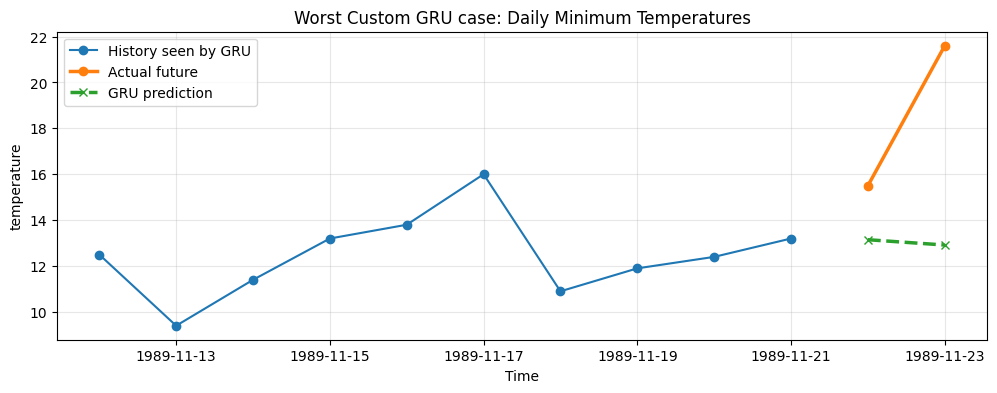

Last few observed rows before the failure:


,timestamp,temperature
5,1989-11-17,16.0
6,1989-11-18,10.9
7,1989-11-19,11.9
8,1989-11-20,12.4
9,1989-11-21,13.2


,timestamp,value,segment
5,1989-11-17,16.0,history
6,1989-11-18,10.9,history
7,1989-11-19,11.9,history
8,1989-11-20,12.4,history
9,1989-11-21,13.2,history
10,1989-11-22,15.5,actual future
11,1989-11-23,21.6,actual future


,timestamp,actual,predicted,abs_error
1,1989-11-23,21.6,12.9157,8.6843
0,1989-11-22,15.5,13.1474,2.3526


Daily Consumption With Weather Context


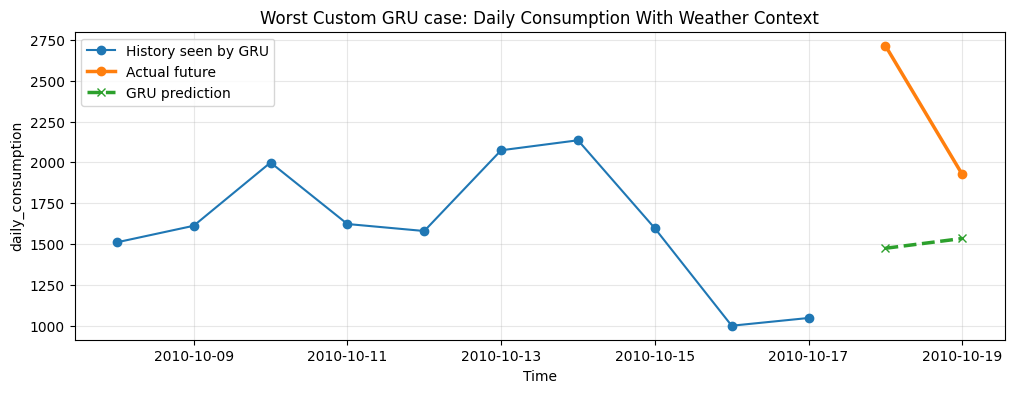

Last few observed rows before the failure:


,timestamp,daily_consumption,AWND,PRCP,TMAX,TMIN
5,2010-10-13,2073.885986,2.0,0.0,17.799999,8.9
6,2010-10-14,2135.122070,1.5,15.5,17.200001,10.0
7,2010-10-15,1596.323975,5.1,0.5,13.900000,9.4
8,2010-10-16,1000.013977,4.7,0.0,14.400000,10.0
9,2010-10-17,1047.381958,2.3,0.0,20.600000,8.9


,timestamp,value,segment
5,2010-10-13,2073.885986,history
6,2010-10-14,2135.122070,history
7,2010-10-15,1596.323975,history
8,2010-10-16,1000.013977,history
9,2010-10-17,1047.381958,history
10,2010-10-18,2713.884033,actual future
11,2010-10-19,1925.978027,actual future


,timestamp,actual,predicted,abs_error
0,2010-10-18,2713.884033,1474.06604,1239.817993
1,2010-10-19,1925.978027,1534.00061,391.977386


In [116]:
def show_worst_gru_case(problem, run):
    sample_idx = run["worst_sample_idx"]
    x_times = pd.to_datetime(problem["samples"]["test"]["x_times"][sample_idx])
    y_times = pd.to_datetime(problem["samples"]["test"]["y_times"][sample_idx])
    x_values = problem["samples"]["test"]["x_target_raw"][sample_idx]
    y_values = problem["samples"]["test"]["y_target_raw"][sample_idx]
    y_pred = run["pred_raw"][sample_idx]
    context_features = pd.DataFrame(
        problem["samples"]["test"]["x_feature_raw"][sample_idx],
        columns=problem["feature_columns"],
    )
    context_features.insert(0, "timestamp", x_times)

    summary = pd.DataFrame(
        {
            "timestamp": list(x_times) + list(y_times),
            "value": list(x_values) + list(y_values),
            "segment": ["history"] * len(x_values) + ["actual future"] * len(y_values),
        }
    )

    plt.figure(figsize=(12, 4))
    plt.plot(x_times, x_values, marker="o", label="History seen by GRU")
    plt.plot(y_times, y_values, marker="o", linewidth=2.5, label="Actual future")
    plt.plot(y_times, y_pred, marker="x", linestyle="--", linewidth=2.5, label="GRU prediction")
    plt.title(f"Worst Custom GRU case: {problem['name']}")
    plt.xlabel("Time")
    plt.ylabel(problem["target_column"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    detailed = pd.DataFrame(
        {
            "timestamp": y_times,
            "actual": y_values,
            "predicted": y_pred,
            "abs_error": np.abs(y_values - y_pred),
        }
    )
    return summary, detailed.sort_values("abs_error", ascending=False), context_features.tail(5)


for dataset_name, problem in problems.items():
    print(dataset_name)
    summary_table, error_table, context_tail = show_worst_gru_case(problem, default_runs[dataset_name]["Custom GRU"])
    print("Last few observed rows before the failure:")
    display(context_tail.round(4))
    display(summary_table.tail(problem["horizon"] + 5))
    display(error_table.round(4))

In [117]:
def show_top_gru_errors(dataset_name, run, top_k: int = 5):
    print(f"Top {top_k} absolute Custom GRU errors for {dataset_name}")
    display(
        run["prediction_frame"]
        .sort_values("abs_error", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
        .round(4)
    )


for dataset_name, dataset_runs in default_runs.items():
    show_top_gru_errors(dataset_name, dataset_runs["Custom GRU"])

Top 5 absolute Custom GRU errors for Daily Minimum Temperatures


,sample_idx,step_ahead,timestamp,actual,predicted,abs_error
0,143,2,1989-11-23,21.6,12.9157,8.6843
1,449,2,1990-09-25,16.3,8.1974,8.1025
2,309,2,1990-05-08,4.9,12.6669,7.7669
3,444,2,1990-09-20,16.3,8.7860,7.5140
4,144,1,1989-11-23,21.6,14.4800,7.1200


Top 5 absolute Custom GRU errors for Daily Consumption With Weather Context


,sample_idx,step_ahead,timestamp,actual,predicted,abs_error
0,175,1,2010-10-18,2713.884,1474.0660,1239.8180
1,153,2,2010-09-25,106.006,1275.1727,1169.1667
2,154,1,2010-09-25,106.006,1257.5884,1151.5824
3,125,1,2010-08-27,2030.650,897.4376,1133.2124
4,124,2,2010-08-27,2030.650,952.4337,1078.2163


Failure Interpretation:

The custom GRU is expected to struggle most when the next two points break sharply away from the recent pattern inside the input window.

Typical reasons:

- the hidden state compresses history into a small vector of size 14,
- abrupt spikes are rare and hard to infer from smooth recent context,
- in the electricity dataset, the model only sees past weather values, so a sudden future weather shift cannot be supplied directly at prediction time.

Ablation: How Much History Should the GRU See?

The assignment asks us to test the custom GRU with:

- half window size: 5
- original window size: 10
- double window size: 20

This ablation is useful because time-series forecasting is a trade-off:

- too short a window may miss seasonal structure.
- too long a window may inject stale or distracting information.

In [118]:
window_variants = {
    "half": max(1, window_size // 2),
    "original": window_size,
    "double": window_size * 2,
}

ablation_rows = []
ablation_runs = {}

for dataset_name, dataset_info in raw_series_catalog.items():
    ablation_runs[dataset_name] = {}
    for label, variant_window_size in window_variants.items():
        variant_problem = build_windowed_problem(dataset_info, variant_window_size, prediction_horizon)
        run = run_single_experiment(
            variant_problem,
            model_name=f"Custom GRU ({label})",
            model_builder=lambda problem: CustomGRU(problem["num_features"], hidden_size, prediction_horizon),
        )
        ablation_runs[dataset_name][label] = {"problem": variant_problem, "run": run}
        ablation_rows.append(
            {
                "dataset": dataset_name,
                "window_variant": label,
                "window_size": variant_window_size,
                **run["metrics"],
            }
        )

ablation_df = pd.DataFrame(ablation_rows).sort_values(["dataset", "window_size"]).reset_index(drop=True)
ablation_df.round(4)

,dataset,window_variant,window_size,MSE,MAE,RMSE
0,Daily Consumption With Weather Context,half,5,128691.9375,275.3818,358.7366
1,Daily Consumption With Weather Context,original,10,128007.3828,275.2765,357.7812
2,Daily Consumption With Weather Context,double,20,123180.6641,267.5872,350.9710
3,Daily Minimum Temperatures,half,5,5.9966,1.9091,2.4488
4,Daily Minimum Temperatures,original,10,5.7237,1.8574,2.3924
5,Daily Minimum Temperatures,double,20,5.6954,1.8442,2.3865


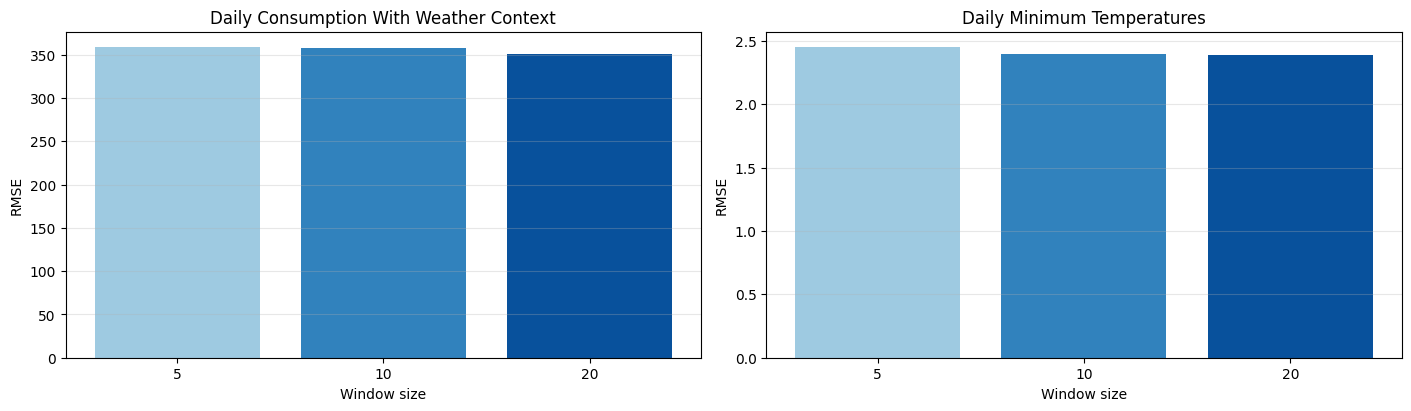

In [119]:
def plot_ablation(ablation_table: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

    for ax, dataset_name in zip(axes, ablation_table["dataset"].unique()):
        subset = ablation_table[ablation_table["dataset"] == dataset_name].sort_values("window_size")
        ax.bar(subset["window_size"].astype(str), subset["RMSE"], color=["#9ecae1", "#3182bd", "#08519c"])
        ax.set_title(dataset_name)
        ax.set_xlabel("Window size")
        ax.set_ylabel("RMSE")
        ax.grid(axis="y", alpha=0.3)

    plt.show()


plot_ablation(ablation_df)

In [120]:
for dataset_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == dataset_name].sort_values("RMSE")
    best_row = subset.iloc[0]
    worst_row = subset.iloc[-1]
    print(dataset_name)
    print(
        f"  Best GRU window: {int(best_row['window_size'])} "
        f"(RMSE={best_row['RMSE']:.4f})"
    )
    print(
        f"  Weakest GRU window: {int(worst_row['window_size'])} "
        f"(RMSE={worst_row['RMSE']:.4f})"
    )
    print()

Daily Consumption With Weather Context
  Best GRU window: 20 (RMSE=350.9710)
  Weakest GRU window: 5 (RMSE=358.7366)

Daily Minimum Temperatures
  Best GRU window: 20 (RMSE=2.3865)
  Weakest GRU window: 5 (RMSE=2.4488)

